<a href="https://colab.research.google.com/github/melia1702/Pertemuan-ketigabelas/blob/main/PRAKTIKUM_13_1_MG_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LATIHAN 1: KNN UNTUK DIGIT RECOGNITION
Dataset Shape: (1797, 64)
Number of Classes: 10


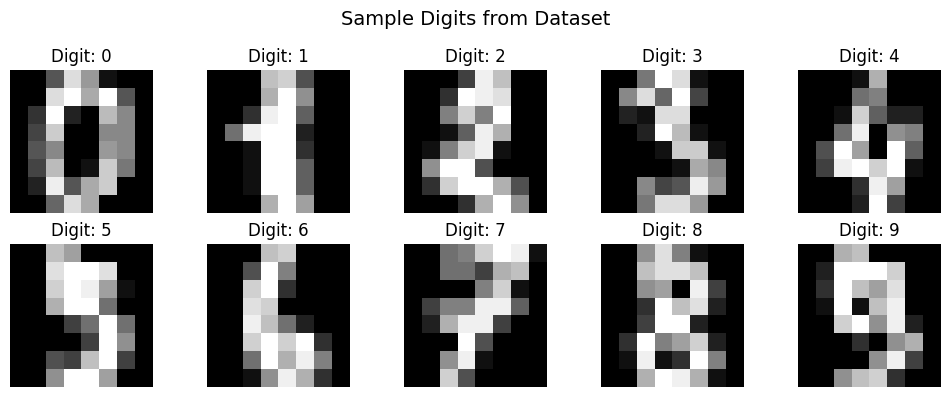

k=1: CV Accuracy=0.9865, Test Accuracy=0.9870
k=3: CV Accuracy=0.9849, Test Accuracy=0.9870
k=5: CV Accuracy=0.9825, Test Accuracy=0.9870
k=7: CV Accuracy=0.9801, Test Accuracy=0.9833
k=9: CV Accuracy=0.9769, Test Accuracy=0.9778
k=11: CV Accuracy=0.9729, Test Accuracy=0.9796


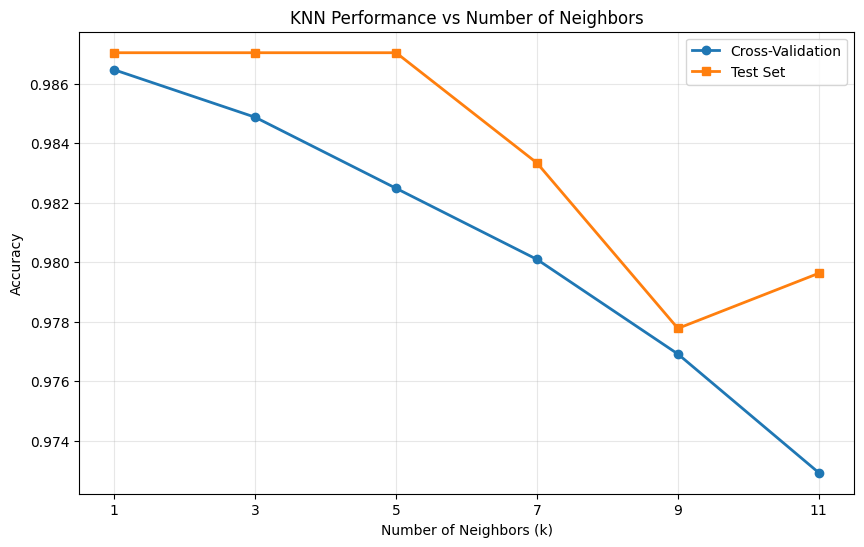


Best k value: 1


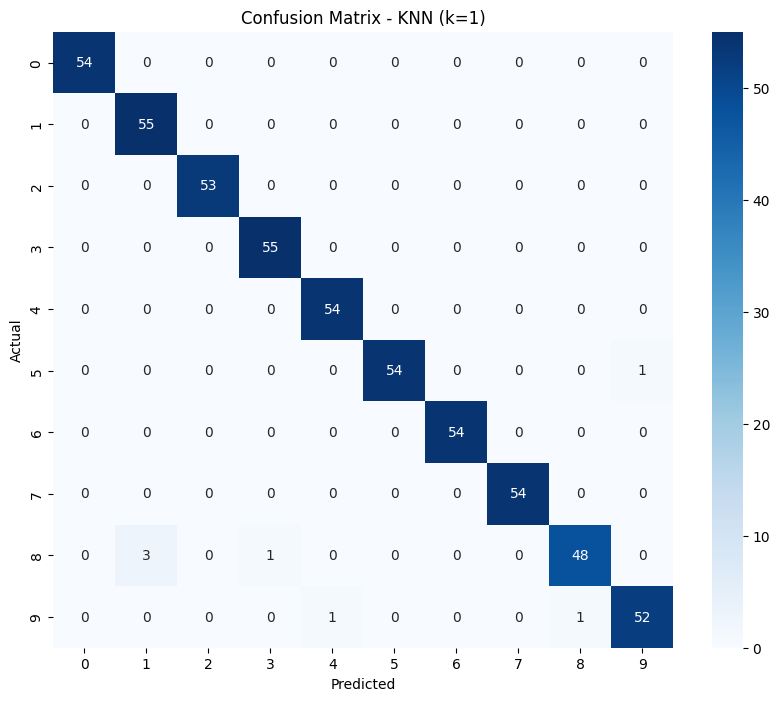


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       1.00      1.00      1.00        53
           3       0.98      1.00      0.99        55
           4       0.98      1.00      0.99        54
           5       1.00      0.98      0.99        55
           6       1.00      1.00      1.00        54
           7       1.00      1.00      1.00        54
           8       0.98      0.92      0.95        52
           9       0.98      0.96      0.97        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540


Number of misclassifications: 7/540 (1.30%)

Sample Misclassifications:


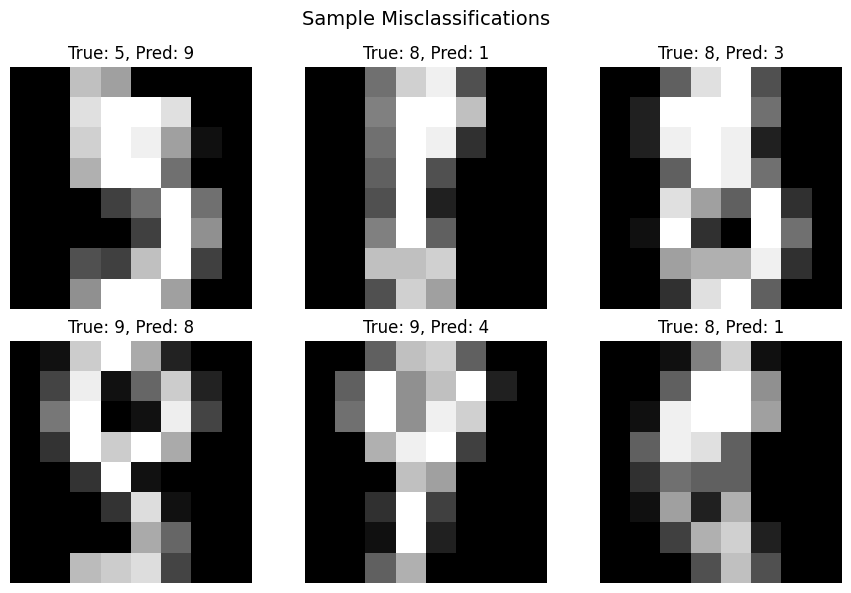

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Latihan 1: KNN untuk Digit Recognition
def praktikum_knn_digit():
    print("LATIHAN 1: KNN UNTUK DIGIT RECOGNITION")
    print("=" * 50)

    # Load dataset digit MNIST
    digits = load_digits()
    X = digits.data
    y = digits.target

    print(f"Dataset Shape: {X.shape}")
    print(f"Number of Classes: {len(np.unique(y))}")

    # Visualize sample digits
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[i].reshape(8, 8), cmap='gray')
        ax.set_title(f"Digit: {y[i]}")
        ax.axis('off')
    plt.suptitle("Sample Digits from Dataset", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Experiment with different k values
    k_values = [1, 3, 5, 7, 9, 11]
    cv_scores = []
    test_scores = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)

        # Cross-validation score
        cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        cv_scores.append(cv_score.mean())

        # Test score
        knn.fit(X_train, y_train)
        test_score = knn.score(X_test, y_test)
        test_scores.append(test_score)

        print(f"k={k}: CV Accuracy={cv_score.mean():.4f}, Test Accuracy={test_score:.4f}")

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, cv_scores, 'o-', label='Cross-Validation', linewidth=2)
    plt.plot(k_values, test_scores, 's-', label='Test Set', linewidth=2)
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Accuracy')
    plt.title('KNN Performance vs Number of Neighbors')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values)
    plt.show()

    # Choose best k and evaluate
    best_k = k_values[np.argmax(cv_scores)]
    print(f"\nBest k value: {best_k}")

    knn_best = KNeighborsClassifier(n_neighbors=best_k)
    knn_best.fit(X_train, y_train)
    y_pred = knn_best.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.title(f'Confusion Matrix - KNN (k={best_k})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Error analysis
    errors = np.where(y_pred != y_test)[0]
    print(f"\nNumber of misclassifications: {len(errors)}/{len(y_test)} ({len(errors)/len(y_test)*100:.2f}%)")

    if len(errors) > 0:
        print("\nSample Misclassifications:")
        fig, axes = plt.subplots(2, 3, figsize=(9, 6))
        for i, idx in enumerate(errors[:6]):
            ax = axes[i//3, i%3]
            ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
            ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
            ax.axis('off')
        plt.suptitle("Sample Misclassifications", fontsize=14)
        plt.tight_layout()
        plt.show()

    return knn_best, X_test, y_test, y_pred

# Jalankan latihan 1
knn_model, X_test, y_test, y_pred = praktikum_knn_digit()